# NATRE Calculating Terms

This notebook is for taking individual profiles and calculating terms 2, 3, and 4 of the simplified tracer variance budget from Ferrari & Polzin (2005). I think I will just start by taking an example profile (in p and p_bar space) and attempting to calculate each term. 2 and 3 will be straightforward, 4 might be a little more interesting.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw
import mixsea as mx
from scipy.ndimage import gaussian_filter1d

In [2]:
import os
os.chdir('/home/amf2288/argo-intern/funcs')
import filt_funcs as ff

## Load datasets, select NATRE region

In [73]:
if 'OUT' not in globals():
    OUT = '/swot/SUM05/amf2288/'

ds_p = xr.open_zarr(OUT + 'complete_ds_p.zarr', consolidated=True,
                    chunks={'PROFILE': 2500})
ds_r = xr.open_zarr(OUT + 'complete_ds_r.zarr', consolidated=True,
                    chunks={'PROFILE': 2500})
ds_pbar = xr.open_zarr(OUT + 'complete_ds_pbar.zarr', consolidated=True,
                       chunks={'PROFILE': 2500})

# The stored PROFILE ids are not unique, which breaks alignment-based operations.
ds_p, ds_r, ds_pbar = [
    dataset.assign_coords(PROFILE=np.arange(dataset.sizes['PROFILE']))
    for dataset in (ds_p, ds_r, ds_pbar)
]

for name, dataset in [('ds_p', ds_p), ('ds_r', ds_r), ('ds_pbar', ds_pbar)]:
    print(f'{name}: {dict(dataset.sizes)}')

ds_p: {'PROFILE': 2550896, 'PRESSURE': 1001}
ds_r: {'PROFILE': 2550896, 'DENSITY': 6000}
ds_pbar: {'PROFILE': 2550896, 'PRESSURE_mean': 1001}


In [74]:
# Keep only profiles whose vertical resolution is strictly below 5 m.
# Toggle between these two filters by commenting/uncommenting the relevant block.

# Option 1: average non-NaN sample_rate < 5 m.
avg_sample_rate = ds_p.sample_rate.mean(dim='PRESSURE', skipna=True)
keep = (avg_sample_rate < 10).fillna(False).values
filter_label = 'average sample_rate < 10 m'

# Option 2: every non-NaN sample_rate < 5 m.
#max_sample_rate = ds_p.sample_rate.max(dim='PRESSURE', skipna=True)
#keep = (max_sample_rate < 5).fillna(False).values
##filter_label = 'max sample_rate < 5 m'

n_total = ds_p.sizes['PROFILE']
n_keep = int(keep.sum())
if ds_pbar.sizes['PROFILE'] != n_total:
    raise ValueError('ds_p and ds_pbar must have matching PROFILE dimensions')

print(f'Keeping {n_keep} of {n_total} profiles with {filter_label}')

keep_idx = np.flatnonzero(keep)
ds_p = ds_p.isel(PROFILE=keep_idx)
ds_pbar = ds_pbar.isel(PROFILE=keep_idx)

Keeping 1055564 of 2550896 profiles with average sample_rate < 10 m


In [75]:
def natre_mask(ds):
    return (
        (ds.LAT >= 20) & (ds.LAT <= 31) &
        (ds.LON >= -38) & (ds.LON <= -20) &
        (ds.TIME >= np.datetime64('2014-01-01')) &
        (ds.TIME <  np.datetime64('2025-01-01'))
    ).compute()

# ds_pbar and co_pbar are different profile collections, so each needs a mask
# from its own coords; sharing one makes xarray align on PROFILE label instead.

NATRE_p    = ds_p.where(natre_mask(ds_p), drop=True)
NATRE_pbar = ds_pbar.where(natre_mask(ds_pbar), drop=True)

print(f'{NATRE_p.sizes["PROFILE"]} ds_p profiles, '
      f'{NATRE_pbar.sizes["PROFILE"]} ds_pbar profiles in NATRE box')

4486 ds_p profiles, 4486 ds_pbar profiles in NATRE box


In [76]:
NATRE_p = NATRE_p.drop_vars(['CT_mean','SA_mean','SPICE_mean'])

In [77]:
np.nanmax(NATRE_p.sample_rate.values)

150.0

## Construct variance budget

### Calculate terms 2, 3, 4 on `ds_p`

Everything under this subsection will use the dataset in (interpolated) pressure space. This doesn't account for internal waves, there's no conversion to density, etc. I'm just trying to start with the simplest approach and broaden out from there.

In [78]:
TEMP = NATRE_p.TEMP.values.T
PSAL = NATRE_p.PSAL.values.T
Z    = NATRE_p.PRESSURE.values
LON  = NATRE_p.LON.values
LAT  = NATRE_p.LAT.values

In [79]:
print(f"Finescale")
# Center points of depth windows. Windows are half overlapping, i.e.
# their size (200m) is double the spacing here (100m).
window_size = 200
min_size = 10.
dZ = window_size // 4
print("window size {} m, window spacing {} m".format(window_size, dZ))
depth_bin = np.arange(dZ, 2000, dZ)
# Wavenumber vector. Starts at wavenumber corresponding to a 200m
# wavelength.
m = np.arange(2 * np.pi / window_size, 2 * np.pi / min_size, 2 * np.pi / window_size)
# Wavenumber indices for integration. Shear is integrated from 300m to
# 100m scales. Strain is integrated from 150m to 30m.
m_include_sh = list(range(3))
m_include_st = list(range(1, 12))
N_PROF = len(NATRE_p.PROFILE)

eps_st = np.full( (depth_bin.size, N_PROF), np.nan)
Krho_st = np.full( (depth_bin.size, N_PROF), np.nan)
depth_st = np.full( (depth_bin.size, N_PROF), np.nan)
for i in range(N_PROF):
    if np.sum(np.isfinite(TEMP[:,i]+PSAL[:,i]))<100:
        continue
    try:
        eps_shst, krho_shst, diag = mx.shearstrain.nan_shearstrain(
            Z,
            TEMP[:,i],
            PSAL[:,i],
            LON[i],
            LAT[i],
            TEMP[:,i]*0.,
            TEMP[:,i]*0.,
            Z,
            m=m,
            depth_bin=depth_bin,
            window_size=window_size,
            m_include_sh=m_include_sh,
            m_include_st=m_include_st,
            ladcp_is_shear=True,
            smooth="AL",
            return_diagnostics=True,
        )
    except ValueError as e:
        print(f"Skipped profile at index {i} due to error: {e}")
        continue

    z0 = diag['depth_bin']
    for j in range(z0.size):
        jj = np.where(depth_bin == z0[j])[0]
        if jj.size == 0:
            continue
        eps_st[jj[0],i] =  diag['eps_st'][j]
        Krho_st[jj[0],i] = diag['krho_st'][j]

Finescale
window size 200 m, window spacing 50 m


/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Skipped profile at index 962 due to error: zero-size array to reduction operation maximum which has no identity
Skipped profile at index 4142 due to error: zero-size array to reduction operation maximum which has no identity


In [80]:
NATRE_Krho = xr.Dataset(
    data_vars=dict(
        eps   = (("PRESSURE", "PROFILE"), eps_st),
        Krho  = (("PRESSURE", "PROFILE"), Krho_st),
        depth = (("PRESSURE", "PROFILE"), depth_st),
    ),
    coords=dict(
        PRESSURE = depth_bin,
        PROFILE  = NATRE_p.PROFILE.values,
        LAT      = ("PROFILE", NATRE_p.LAT.values),
        LON      = ("PROFILE", NATRE_p.LON.values),
        TIME     = ("PROFILE", NATRE_p.TIME.values),
    ),
)

In [81]:
NATRE_Krho = NATRE_Krho.interp(PRESSURE=NATRE_p.PRESSURE)

### Save datasets!!!!!!

In [82]:
NATRE_p

<xarray.Dataset>
Dimensions:          (PROFILE: 4486, PRESSURE: 1001)
Coordinates:
    LAT              (PROFILE) float64 26.47 26.5 26.95 ... 25.11 25.17 25.0
    LON              (PROFILE) float64 -25.79 -25.72 -26.26 ... -35.82 -35.26
  * PRESSURE         (PRESSURE) int64 0 2 4 6 8 10 ... 1992 1994 1996 1998 2000
    TIME             (PROFILE) datetime64[ns] 2014-01-09T06:55:42.000000256 ....
  * PROFILE          (PROFILE) int64 51366 51371 51382 ... 2340435 2340438
Data variables: (12/17)
    CT               (PROFILE, PRESSURE) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    CT_sort          (PROFILE, PRESSURE) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    CYCLE_NUMBER     (PROFILE) float64 dask.array<chunksize=(2495,), meta=np.ndarray>
    DATA_MODE        (PROFILE) object dask.array<chunksize=(2495,), meta=np.ndarray>
    DIRECTION        (PROFILE) object dask.array<chunksize=(2495,), meta=np.ndarray>
    PLATFORM_NUMBER  (PROFILE) float64 dask.array<chunksize=(2495,), meta=np.ndarray>
    ...               ...
    sample_rate      (PROFILE, PRESSURE) float32 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    SIG0             (PROFILE, PRESSURE) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    SIG0_sort        (PROFILE, PRESSURE) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    SPICE            (PROFILE, PRESSURE) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    SPICE_sort       (PROFILE, PRESSURE) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    TEMP             (PROFILE, PRESSURE) float32 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         https://data-argo.ifremer.fr
    Fetched_by:           amf2288
    Fetched_date:         2025/03/11
    Fetched_constraints:  [x=0.00/5.00; y=40.00/45.00; z=0.0/2002.0]
    Fetched_uri:          https://data-argo.ifremer.fr/dac/coriolis/6903068/6...
    Valid uris:           ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    All uris:             ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [83]:
NATRE_pbar

<xarray.Dataset>
Dimensions:        (PROFILE: 4486, PRESSURE_mean: 1001)
Coordinates:
    LAT            (PROFILE) float64 26.47 26.5 26.95 26.98 ... 25.11 25.17 25.0
    LON            (PROFILE) float64 -25.79 -25.72 -26.26 ... -35.82 -35.26
  * PRESSURE_mean  (PRESSURE_mean) int64 0 2 4 6 8 ... 1992 1994 1996 1998 2000
    TIME           (PROFILE) datetime64[ns] 2014-01-09T06:55:42.000000256 ......
  * PROFILE        (PROFILE) int64 51366 51371 51382 ... 2340432 2340435 2340438
Data variables:
    CT_sort        (PROFILE, PRESSURE_mean) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    DENSITY        (PROFILE, PRESSURE_mean) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    SA_sort        (PROFILE, PRESSURE_mean) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>
    SPICE_sort     (PROFILE, PRESSURE_mean) float64 dask.array<chunksize=(2495, 1001), meta=np.ndarray>

In [84]:
NATRE_Krho

<xarray.Dataset>
Dimensions:   (PRESSURE: 1001, PROFILE: 4486)
Coordinates:
  * PROFILE   (PROFILE) int64 51366 51371 51382 ... 2340432 2340435 2340438
    LAT       (PROFILE) float64 26.47 26.5 26.95 26.98 ... 25.11 25.17 25.0
    LON       (PROFILE) float64 -25.79 -25.72 -26.26 ... -36.22 -35.82 -35.26
    TIME      (PROFILE) datetime64[ns] 2014-01-09T06:55:42.000000256 ... 2024...
  * PRESSURE  (PRESSURE) int64 0 2 4 6 8 10 12 ... 1990 1992 1994 1996 1998 2000
Data variables:
    eps       (PRESSURE, PROFILE) float64 nan nan nan nan ... nan nan nan nan
    Krho      (PRESSURE, PROFILE) float64 nan nan nan nan ... nan nan nan nan
    depth     (PRESSURE, PROFILE) float64 nan nan nan nan ... nan nan nan nan

In [85]:
NATRE_p.to_netcdf('/swot/SUM05/amf2288/NATRE_datasets/NATRE_p_avg10.nc')
NATRE_pbar.to_netcdf('/swot/SUM05/amf2288/NATRE_datasets/NATRE_pbar_avg10.nc')
NATRE_Krho.to_netcdf('/swot/SUM05/amf2288/NATRE_datasets/NATRE_Krho_avg10.nc')

/tmp/ipykernel_681121/2362923095.py:1: SerializationWarning: variable DATA_MODE has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  NATRE_p.to_netcdf('/swot/SUM05/amf2288/NATRE_datasets/NATRE_p_avg10.nc')
/tmp/ipykernel_681121/2362923095.py:1: SerializationWarning: variable DIRECTION has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  NATRE_p.to_netcdf('/swot/SUM05/amf2288/NATRE_datasets/NATRE_p_avg10.nc')


In [52]:
lfilt = 100

NATRE_p['CTm']    = ff.ds_filt_nan(NATRE_p, lfilt, variable='CT', dim1='PROFILE', dim2='PRESSURE')
NATRE_p['CTe']    = NATRE_p.CT - NATRE_p.CTm
print('CT complete')
NATRE_p['SAm']    = ff.ds_filt_nan(NATRE_p, lfilt, variable='SA', dim1='PROFILE', dim2='PRESSURE')
NATRE_p['SAe']    = NATRE_p.SA - NATRE_p.SAm
print('SA complete')
NATRE_p['SPICEm'] = ff.ds_filt_nan(NATRE_p, lfilt, variable='SPICE', dim1='PROFILE', dim2='PRESSURE')
NATRE_p['SPICEe'] = NATRE_p.SPICE - NATRE_p.SPICEm
print('SPICE complete')

CT complete
SA complete
SPICE complete


In [53]:
dCTm_dz2 = (NATRE_p.CTm.differentiate('PRESSURE'))**2
dCTe_dz2 = ff.ds_filt_nan((NATRE_p.CTe.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
dCT_dz2  = ff.ds_filt_nan((NATRE_p.CT.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
print('CT complete')
dSAm_dz2 = (NATRE_p.SAm.differentiate('PRESSURE'))**2
dSAe_dz2 = ff.ds_filt_nan((NATRE_p.SAe.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
dSA_dz2  = ff.ds_filt_nan((NATRE_p.SA.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
print('SA complete')
dSPICEm_dz2 = (NATRE_p.SPICEm.differentiate('PRESSURE'))**2
dSPICEe_dz2 = ff.ds_filt_nan((NATRE_p.SPICEe.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
dSPICE_dz2  = ff.ds_filt_nan((NATRE_p.SPICE.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
print('SPICE complete')

CT complete
SA complete
SPICE complete


In [54]:
CT2_p = NATRE_Krho.Krho * (dCTe_dz2)
CT3_p = NATRE_Krho.Krho * (dCTm_dz2)
CT4_p = NATRE_Krho.Krho * (dCT_dz2)
print('CT complete')
SA2_p = NATRE_Krho.Krho * (dSAe_dz2)
SA3_p = NATRE_Krho.Krho * (dSAm_dz2)
SA4_p = NATRE_Krho.Krho * (dSA_dz2)
print('SA complete')
SPICE2_p = NATRE_Krho.Krho * (dSPICEe_dz2)
SPICE3_p = NATRE_Krho.Krho * (dSPICEm_dz2)
SPICE4_p = NATRE_Krho.Krho * (dSPICE_dz2)
print('SPICE complete')

CT complete
SA complete
SPICE complete


/tmp/ipykernel_1006286/986077415.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


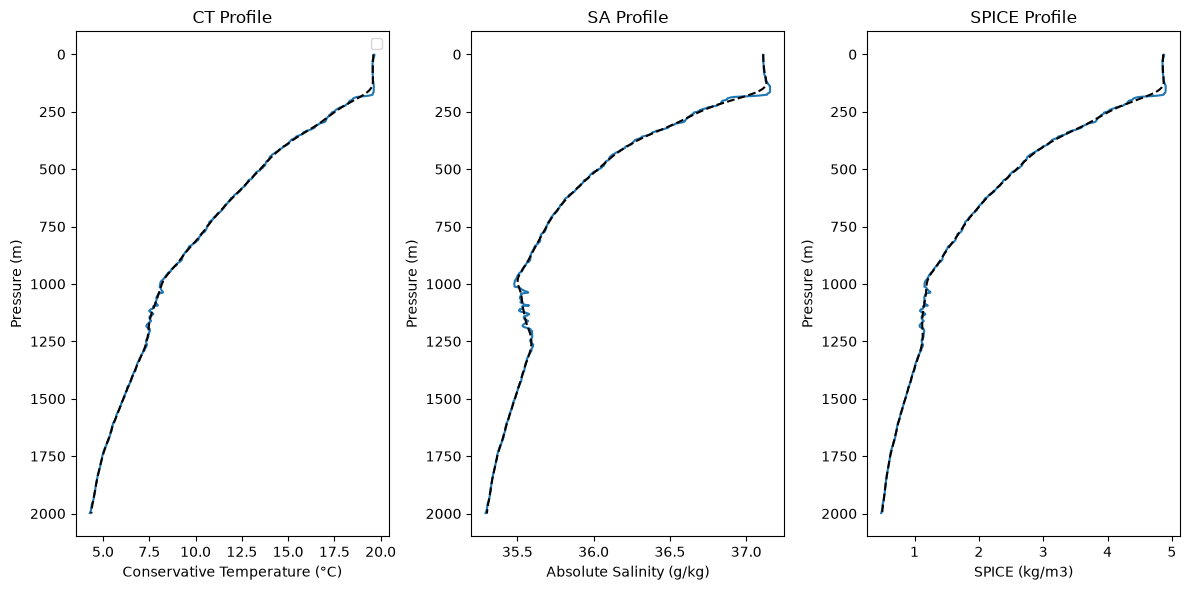

In [55]:
prof = NATRE_p.isel(PROFILE=51)

plt.figure(figsize=(12,6))
plt.subplot(131)
prof.CT.plot(y='PRESSURE')
prof.CTm.plot(y='PRESSURE', color='k', linestyle='--')
plt.gca().invert_yaxis()
plt.xlabel('Conservative Temperature (°C)')
plt.ylabel('Pressure (m)')
plt.legend()
plt.title('CT Profile')

plt.subplot(132)
prof.SA.plot(y='PRESSURE')
prof.SAm.plot(y='PRESSURE', color='k', linestyle='--')
plt.gca().invert_yaxis()
plt.xlabel('Absolute Salinity (g/kg)')
plt.ylabel('Pressure (m)')
plt.title('SA Profile')

plt.subplot(133)
prof.SPICE.plot(y='PRESSURE', label='Observed C')
prof.SPICEm.plot(y='PRESSURE', color='k', linestyle='--', label='Mean C')
plt.gca().invert_yaxis()
plt.xlabel('SPICE (kg/m3)')
plt.ylabel('Pressure (m)')
plt.title('SPICE Profile')

plt.tight_layout()

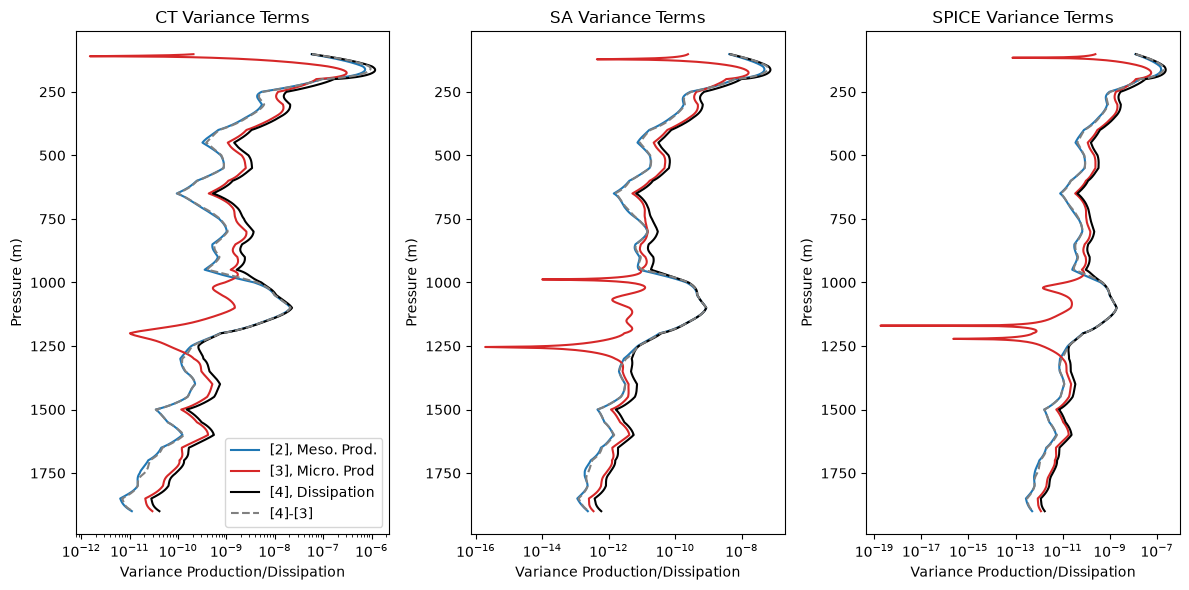

In [56]:
plt.figure(figsize=(12,6))

plt.subplot(131)
CT2_p.isel(PROFILE=51).plot(y='PRESSURE', color='tab:blue', label='[2], Meso. Prod.')
CT3_p.isel(PROFILE=51).plot(y='PRESSURE', color='tab:red', label='[3], Micro. Prod')
CT4_p.isel(PROFILE=51).plot(y='PRESSURE', color='k', label='[4], Dissipation')
(CT4_p.isel(PROFILE=51)-CT3_p.isel(PROFILE=51)).plot(y='PRESSURE', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('Pressure (m)')
plt.legend()
plt.title('CT Variance Terms')

plt.subplot(132)
SA2_p.isel(PROFILE=51).plot(y='PRESSURE', color='tab:blue')
SA3_p.isel(PROFILE=51).plot(y='PRESSURE', color='tab:red')
SA4_p.isel(PROFILE=51).plot(y='PRESSURE', color='k')
(SA4_p.isel(PROFILE=51)-SA3_p.isel(PROFILE=51)).plot(y='PRESSURE', color='gray', linestyle='--')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('Pressure (m)')
plt.title('SA Variance Terms')


plt.subplot(133)
SPICE2_p.isel(PROFILE=51).plot(y='PRESSURE', color='tab:blue')
SPICE3_p.isel(PROFILE=51).plot(y='PRESSURE', color='tab:red')
SPICE4_p.isel(PROFILE=51).plot(y='PRESSURE', color='k')
(SPICE4_p.isel(PROFILE=51)-SPICE3_p.isel(PROFILE=51)).plot(y='PRESSURE', color='gray', linestyle='--')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('Pressure (m)')
plt.title('SPICE Variance Terms')

plt.tight_layout()

### Calculate terms 2, 3, 4 on `ds_pbar`

Same as above, except for now I use reindexed tracer variables that have been converted to density space, then to average isopycnal depth space (pbar). Note that this is **only for vertical gradients NOT calculating profiles of K_rho**. I still use the observed profiles as inputs to the `mixsea` package for calculating K_rho.

In [57]:
lfilt = 100

NATRE_pbar['CTm']    = ff.ds_filt_nan(NATRE_pbar, lfilt, variable='CT_sort', dim1='PROFILE', dim2='PRESSURE_mean')
NATRE_pbar['CTe']    = NATRE_pbar.CT_sort - NATRE_pbar.CTm
print('CT complete')
NATRE_pbar['SAm']    = ff.ds_filt_nan(NATRE_pbar, lfilt, variable='SA_sort', dim1='PROFILE', dim2='PRESSURE_mean')
NATRE_pbar['SAe']    = NATRE_pbar.SA_sort - NATRE_pbar.SAm
print('SA complete')
NATRE_pbar['SPICEm'] = ff.ds_filt_nan(NATRE_pbar, lfilt, variable='SPICE_sort', dim1='PROFILE', dim2='PRESSURE_mean')
NATRE_pbar['SPICEe'] = NATRE_pbar.SPICE_sort - NATRE_pbar.SPICEm
print('SPICE complete')

CT complete
SA complete
SPICE complete


In [58]:
dCTm_dz2 = (NATRE_pbar.CTm.differentiate('PRESSURE_mean'))**2
dCTe_dz2 = ff.ds_filt_nan((NATRE_pbar.CTe.differentiate('PRESSURE_mean')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE_mean')
dCT_dz2  = ff.ds_filt_nan((NATRE_p.CT.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE').rename({'PRESSURE':'PRESSURE_mean'})
print('CT complete')
dSAm_dz2 = (NATRE_pbar.SAm.differentiate('PRESSURE_mean'))**2
dSAe_dz2 = ff.ds_filt_nan((NATRE_pbar.SAe.differentiate('PRESSURE_mean')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE_mean')
dSA_dz2  = ff.ds_filt_nan((NATRE_p.SA.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE').rename({'PRESSURE':'PRESSURE_mean'})
print('SA complete')
dSPICEm_dz2 = (NATRE_pbar.SPICEm.differentiate('PRESSURE_mean'))**2
dSPICEe_dz2 = ff.ds_filt_nan((NATRE_pbar.SPICEe.differentiate('PRESSURE_mean')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE_mean')
dSPICE_dz2  = ff.ds_filt_nan((NATRE_p.SPICE.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE').rename({'PRESSURE':'PRESSURE_mean'})
print('SPICE complete')

CT complete
SA complete
SPICE complete


In [59]:
CT2_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dCTe_dz2)
CT3_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dCTm_dz2)
CT4_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dCT_dz2)
print('CT complete')
SA2_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dSAe_dz2)
SA3_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dSAm_dz2)
SA4_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dSA_dz2)
print('SA complete')
SPICE2_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dSPICEe_dz2)
SPICE3_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dSPICEm_dz2)
SPICE4_pbar = NATRE_Krho.Krho.rename({'PRESSURE':'PRESSURE_mean'}) * (dSPICE_dz2)
print('SPICE complete')

CT complete
SA complete
SPICE complete


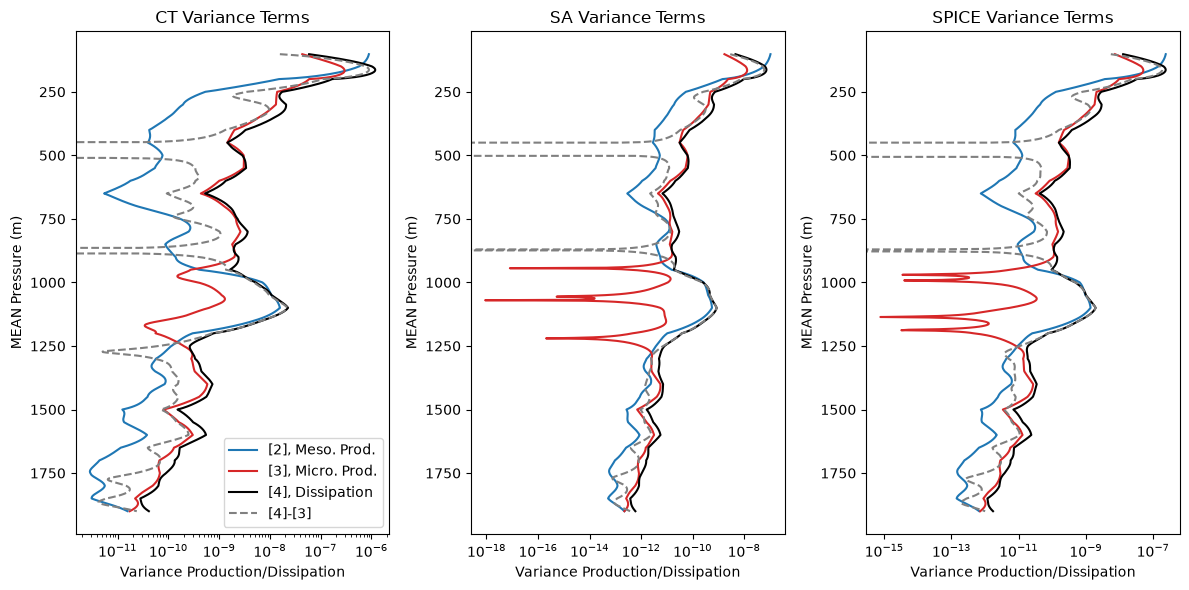

In [60]:
plt.figure(figsize=(12,6))

plt.subplot(131)
CT2_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='tab:blue', label='[2], Meso. Prod.')
CT3_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='tab:red', label='[3], Micro. Prod.')
CT4_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='k', label='[4], Dissipation')
(CT4_pbar.isel(PROFILE=51)-CT3_pbar.isel(PROFILE=51)).plot(y='PRESSURE_mean', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('MEAN Pressure (m)')
plt.legend()
plt.title('CT Variance Terms')

plt.subplot(132)
SA2_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='tab:blue')
SA3_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='tab:red')
SA4_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='k')
(SA4_pbar.isel(PROFILE=51)-SA3_pbar.isel(PROFILE=51)).plot(y='PRESSURE_mean', color='gray', linestyle='--')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('MEAN Pressure (m)')
plt.title('SA Variance Terms')


plt.subplot(133)
SPICE2_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='tab:blue')
SPICE3_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='tab:red')
SPICE4_pbar.isel(PROFILE=51).plot(y='PRESSURE_mean', color='k')
(SPICE4_pbar.isel(PROFILE=51)-SPICE3_pbar.isel(PROFILE=51)).plot(y='PRESSURE_mean', color='gray', linestyle='--')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('MEAN Pressure (m)')
plt.title('SPICE Variance Terms')

plt.tight_layout()

## Comparison to Smith & Ferrari (2005)

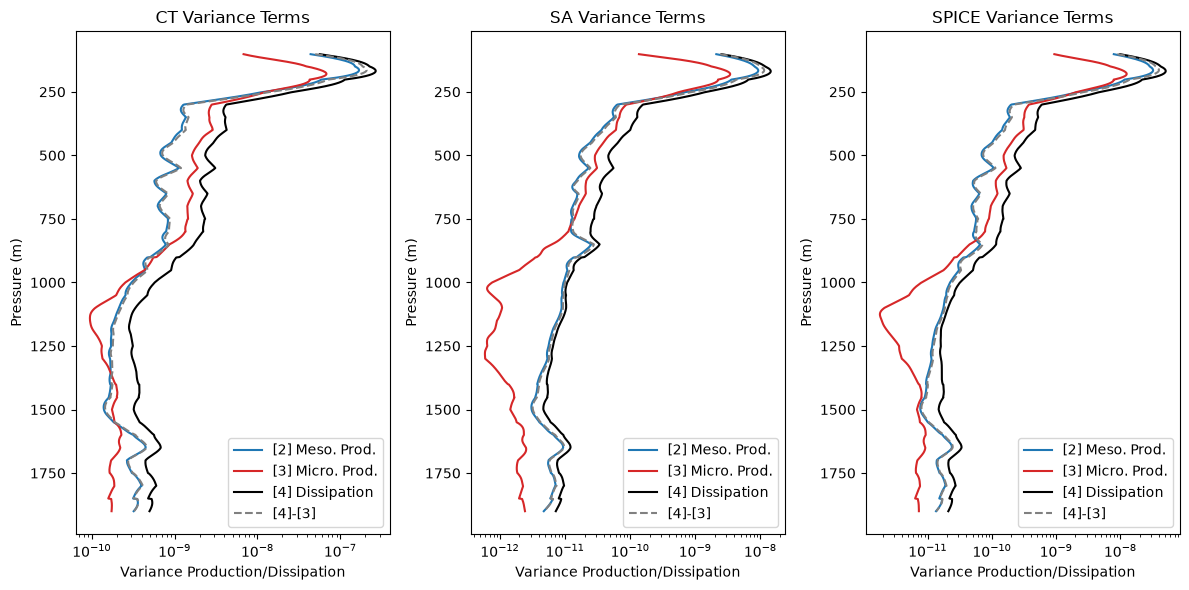

In [61]:
plt.figure(figsize=(12,6))

plt.subplot(131)
CT2_p.mean('PROFILE').plot(y='PRESSURE', color='tab:blue', label='[2] Meso. Prod.')
CT3_p.mean('PROFILE').plot(y='PRESSURE', color='tab:red', label='[3] Micro. Prod.')
(CT4_p.mean('PROFILE')).plot(y='PRESSURE', color='k', label='[4] Dissipation')
(CT4_p - CT3_p).mean('PROFILE').plot(y='PRESSURE', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('Pressure (m)')
plt.legend()
plt.title('CT Variance Terms')

plt.subplot(132)
SA2_p.mean('PROFILE').plot(y='PRESSURE', color='tab:blue', label='[2] Meso. Prod.')
SA3_p.mean('PROFILE').plot(y='PRESSURE', color='tab:red', label='[3] Micro. Prod.')
SA4_p.mean('PROFILE').plot(y='PRESSURE', color='k', label='[4] Dissipation')
(SA4_p - SA3_p).mean('PROFILE').plot(y='PRESSURE', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('Pressure (m)')
plt.legend()
plt.title('SA Variance Terms')

plt.subplot(133)
SPICE2_p.mean('PROFILE').plot(y='PRESSURE', color='tab:blue', label='[2] Meso. Prod.')
SPICE3_p.mean('PROFILE').plot(y='PRESSURE', color='tab:red', label='[3] Micro. Prod.')
SPICE4_p.mean('PROFILE').plot(y='PRESSURE', color='k', label='[4] Dissipation')
(SPICE4_p - SPICE3_p).mean('PROFILE').plot(y='PRESSURE', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('Pressure (m)')
plt.legend()
plt.title('SPICE Variance Terms')

plt.tight_layout()

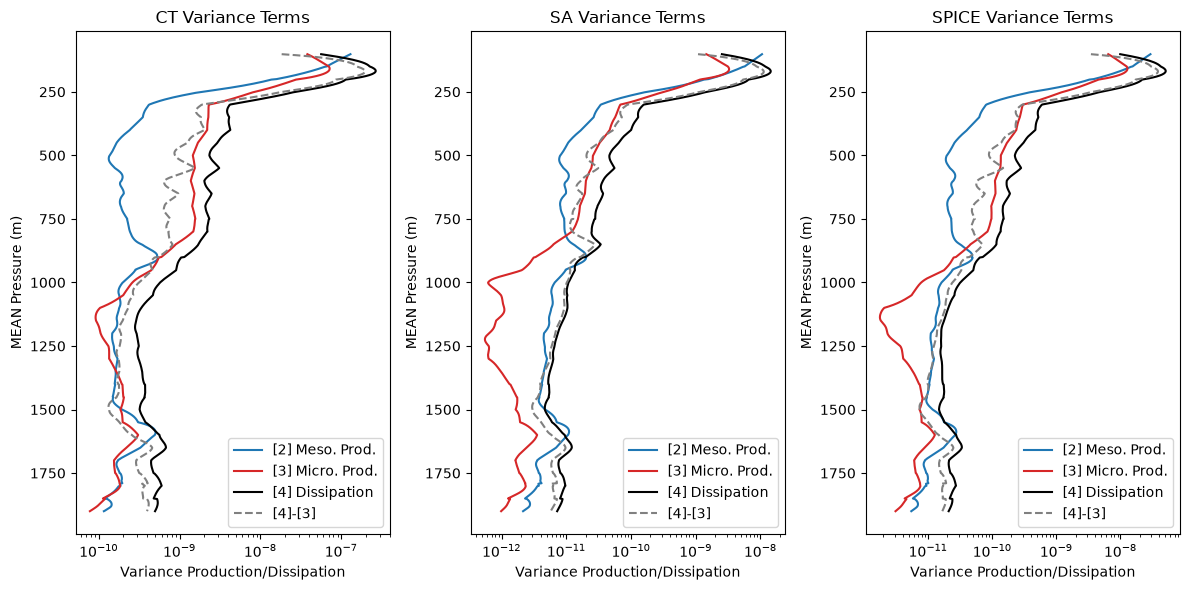

In [62]:
plt.figure(figsize=(12,6))

plt.subplot(131)
CT2_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='tab:blue', label='[2] Meso. Prod.')
CT3_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='tab:red', label='[3] Micro. Prod.')
(CT4_pbar.mean('PROFILE')).plot(y='PRESSURE_mean', color='k', label='[4] Dissipation')
(CT4_pbar - CT3_pbar).mean('PROFILE').plot(y='PRESSURE_mean', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('MEAN Pressure (m)')
plt.legend()
plt.title('CT Variance Terms')

plt.subplot(132)
SA2_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='tab:blue', label='[2] Meso. Prod.')
SA3_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='tab:red', label='[3] Micro. Prod.')
SA4_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='k', label='[4] Dissipation')
(SA4_pbar - SA3_pbar).mean('PROFILE').plot(y='PRESSURE_mean', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('MEAN Pressure (m)')
plt.legend()
plt.title('SA Variance Terms')

plt.subplot(133)
SPICE2_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='tab:blue', label='[2] Meso. Prod.')
SPICE3_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='tab:red', label='[3] Micro. Prod.')
SPICE4_pbar.mean('PROFILE').plot(y='PRESSURE_mean', color='k', label='[4] Dissipation')
(SPICE4_pbar - SPICE3_pbar).mean('PROFILE').plot(y='PRESSURE_mean', color='gray', linestyle='--', label='[4]-[3]')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.ylabel('MEAN Pressure (m)')
plt.legend()
plt.title('SPICE Variance Terms')

plt.tight_layout()

In [63]:
os.chdir('/home/amf2288/argo-intern/notebooks/argo_pbar')

K_mean = NATRE_Krho.Krho.mean('PROFILE')
FP_K_rho = pd.read_csv('CB_Fig2/FP_K_rho.csv', header=None)
CB_K_rho = pd.read_csv('CB_Fig2/CB_K_rho.csv', header=None)

P_para_CT = CT2_p.mean('PROFILE')
P_perp_CT = CT3_p.mean('PROFILE')
P_para_SA = SA2_p.mean('PROFILE')
P_perp_SA = SA3_p.mean('PROFILE')

FP_P_perp_CT = pd.read_csv('CB_Fig2/FP_P_perp_CT.csv', header=None)
FP_P_para_CT = pd.read_csv('CB_Fig2/FP_P_para_CT.csv', header=None)
CB_P_perp_CT = pd.read_csv('CB_Fig2/CB_P_perp_CT.csv', header=None)
CB_P_para_CT = pd.read_csv('CB_Fig2/CB_P_para_CT.csv', header=None)
FP_P_perp_SA = pd.read_csv('CB_Fig2/FP_P_perp_SA.csv', header=None)
FP_P_para_SA = pd.read_csv('CB_Fig2/FP_P_para_SA.csv', header=None)
CB_P_perp_SA = pd.read_csv('CB_Fig2/CB_P_perp_SA.csv', header=None)
CB_P_para_SA = pd.read_csv('CB_Fig2/CB_P_para_SA.csv', header=None)

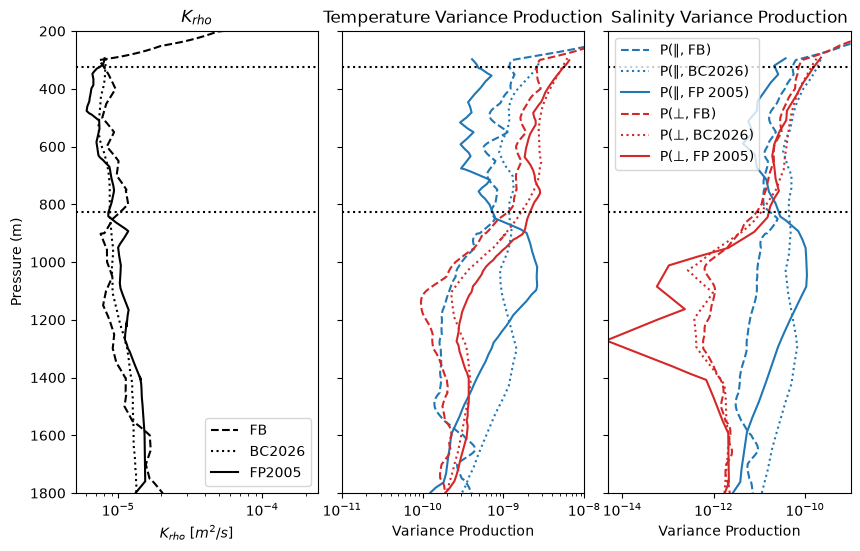

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(131)
K_mean.plot(y='PRESSURE', color='k', linestyle='--', label='FB')
plt.plot(CB_K_rho[0], CB_K_rho[1], color='k', linestyle=':', label='BC2026')
plt.plot(FP_K_rho[0], FP_K_rho[1], color='k', label='FP2005')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('Pressure (m)')
plt.ylim(1800,200)
plt.xscale('log')
plt.xlabel('$K_{rho}$ [$m^2/s$]')
plt.title('$K_{rho}$')

plt.subplot(132)
P_para_CT.plot(y='PRESSURE', color='tab:blue', linestyle='--', label='P(∥, FB)')
plt.plot(CB_P_para_CT[0], CB_P_para_CT[1], color='tab:blue', linestyle=':', label='P(∥, BC2026)')
plt.plot(FP_P_para_CT[0], FP_P_para_CT[1], color='tab:blue', label='P(∥, FP2005)')
P_perp_CT.plot(y='PRESSURE', color='tab:red', linestyle='--', label='P(⊥, FB)')
plt.plot(CB_P_perp_CT[0], CB_P_perp_CT[1], color='tab:red', linestyle=':', label='P(⊥, BC2026)')
plt.plot(FP_P_perp_CT[0], FP_P_perp_CT[1], color='tab:red', label='P(⊥, FP 2005)')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
#plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(1e-11, 1e-8)
plt.xlabel('Variance Production')
plt.title('Temperature Variance Production')

plt.subplot(133)
P_para_SA.plot(y='PRESSURE', color='tab:blue', linestyle='--', label='P(∥, FB)')
plt.plot(CB_P_para_SA[0], CB_P_para_SA[1], color='tab:blue', linestyle=':', label='P(∥, BC2026)')
plt.plot(FP_P_para_SA[0], FP_P_para_SA[1], color='tab:blue', label='P(∥, FP 2005)')
P_perp_SA.plot(y='PRESSURE', color='tab:red', linestyle='--', label='P(⊥, FB)')
plt.plot(CB_P_perp_SA[0], CB_P_perp_SA[1], color='tab:red', linestyle=':', label='P(⊥, BC2026)')
plt.plot(FP_P_perp_SA[0], FP_P_perp_SA[1], color='tab:red', label='P(⊥, FP 2005)')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(5e-15, 1e-9)
plt.xlabel('Variance Production')
plt.title('Salinity Variance Production')

plt.subplots_adjust(wspace=0.1)

In [65]:
K_mean = NATRE_Krho.Krho.mean('PROFILE').rename({'PRESSURE':'PRESSURE_mean'}).sel(PRESSURE_mean=slice(300, None))
P_para_CT = CT2_pbar.mean('PROFILE')
P_perp_CT = CT3_pbar.mean('PROFILE')
P_para_SA = SA2_pbar.mean('PROFILE')
P_perp_SA = SA3_pbar.mean('PROFILE')

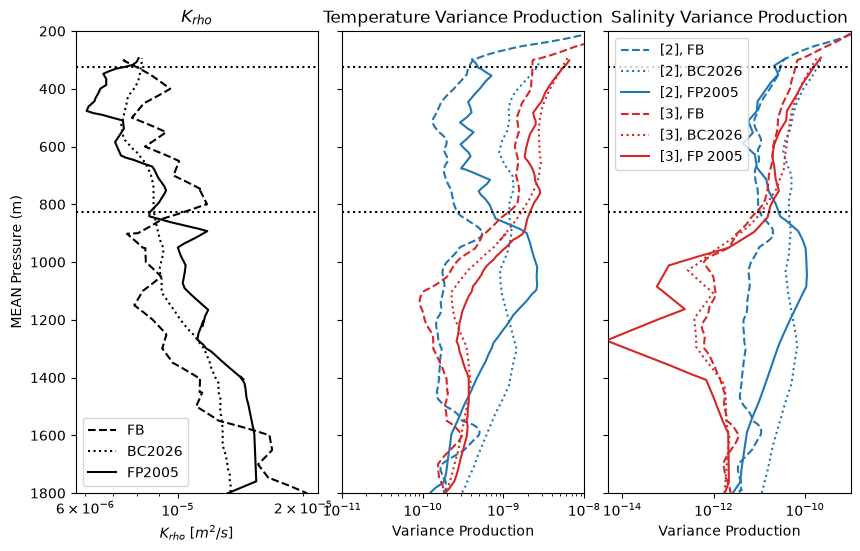

In [66]:
plt.figure(figsize=(10,6))

plt.subplot(131)
K_mean.plot(y='PRESSURE_mean', color='k', linestyle='--', label='FB')
plt.plot(CB_K_rho[0], CB_K_rho[1], color='k', linestyle=':', label='BC2026')
plt.plot(FP_K_rho[0], FP_K_rho[1], color='k', label='FP2005')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('MEAN Pressure (m)')
plt.ylim(1800,200)
plt.xscale('log')
plt.xlabel('$K_{rho}$ [$m^2/s$]')
plt.title('$K_{rho}$')

plt.subplot(132)
P_para_CT.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='[2], FB')
plt.plot(CB_P_para_CT[0], CB_P_para_CT[1], color='tab:blue', linestyle=':', label='[2], BC2026')
plt.plot(FP_P_para_CT[0], FP_P_para_CT[1], color='tab:blue', label='[2], FP2005')
P_perp_CT.plot(y='PRESSURE_mean', color='tab:red', linestyle='--', label='[3], FB')
plt.plot(CB_P_perp_CT[0], CB_P_perp_CT[1], color='tab:red', linestyle=':', label='[3], BC2026')
plt.plot(FP_P_perp_CT[0], FP_P_perp_CT[1], color='tab:red', label='[3], FP2005')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
#plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(1e-11, 1e-8)
plt.xlabel('Variance Production')
plt.title('Temperature Variance Production')

plt.subplot(133)
P_para_SA.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='[2], FB')
plt.plot(CB_P_para_SA[0], CB_P_para_SA[1], color='tab:blue', linestyle=':', label='[2], BC2026')
plt.plot(FP_P_para_SA[0], FP_P_para_SA[1], color='tab:blue', label='[2], FP2005')
P_perp_SA.plot(y='PRESSURE_mean', color='tab:red', linestyle='--', label='[3], FB')
plt.plot(CB_P_perp_SA[0], CB_P_perp_SA[1], color='tab:red', linestyle=':', label='[3], BC2026')
plt.plot(FP_P_perp_SA[0], FP_P_perp_SA[1], color='tab:red', label='[3], FP 2005')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('')
plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(5e-15, 1e-9)
plt.xlabel('Variance Production')
plt.title('Salinity Variance Production')

plt.subplots_adjust(wspace=0.1)

## Follow the method of Broullón et al (2026)

In [67]:
chi_CT = 2 * NATRE_Krho.Krho.mean('PROFILE') * ff.ds_filt_nan((NATRE_p.CT.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE').mean('PROFILE')
chi_SA = 2 * NATRE_Krho.Krho.mean('PROFILE') * ff.ds_filt_nan((NATRE_p.SA.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE').mean('PROFILE')

In [68]:
P_perp_CT = 2 * NATRE_Krho.Krho.mean('PROFILE') * (NATRE_pbar.CT_sort.mean('PROFILE').differentiate('PRESSURE_mean')**2).rename({'PRESSURE_mean':'PRESSURE'})
P_perp_SA = 2 * NATRE_Krho.Krho.mean('PROFILE') * (NATRE_pbar.SA_sort.mean('PROFILE').differentiate('PRESSURE_mean')**2).rename({'PRESSURE_mean':'PRESSURE'})

In [69]:
P_para_CT = chi_CT - P_perp_CT
P_para_SA = chi_SA - P_perp_SA

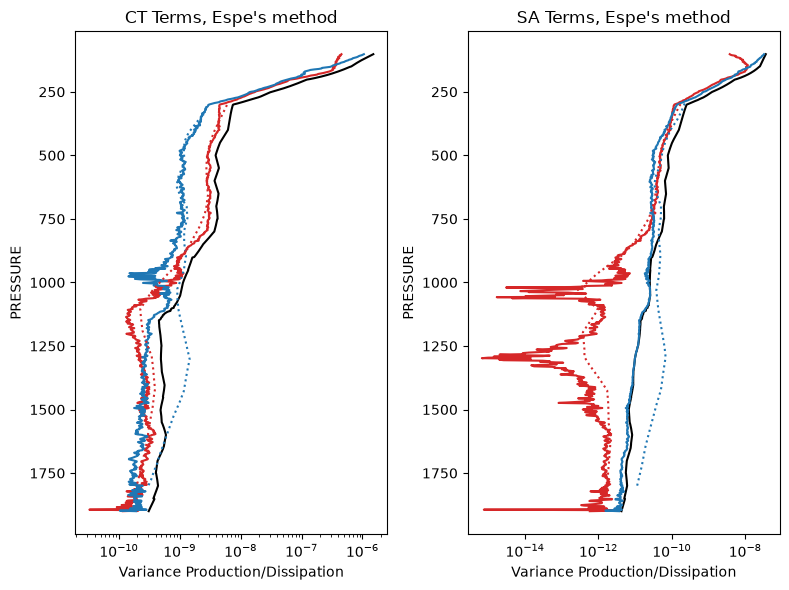

In [70]:
plt.figure(figsize=(8,6))

plt.subplot(121)
chi_CT.plot(y='PRESSURE', color='k')
P_perp_CT.plot(y='PRESSURE', color='tab:red')
P_para_CT.plot(y='PRESSURE', color='tab:blue')
plt.plot(CB_P_para_CT[0], CB_P_para_CT[1], color='tab:blue', linestyle=':', label='[2], BC2026')
plt.plot(CB_P_perp_CT[0], CB_P_perp_CT[1], color='tab:red', linestyle=':', label='[2], BC2026')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.title("CT Terms, Espe's method")

plt.subplot(122)
chi_SA.plot(y='PRESSURE', color='k')
P_perp_SA.plot(y='PRESSURE', color='tab:red')
P_para_SA.plot(y='PRESSURE', color='tab:blue')
plt.plot(CB_P_para_SA[0], CB_P_para_SA[1], color='tab:blue', linestyle=':', label='[2], BC2026')
plt.plot(CB_P_perp_SA[0], CB_P_perp_SA[1], color='tab:red', linestyle=':', label='[2], BC2026')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Variance Production/Dissipation')
plt.title("SA Terms, Espe's method")

plt.tight_layout()

# Different Profile Resolutions

In [3]:
FP_K_rho = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/FP_K_rho.csv', header=None)
CB_K_rho = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/CB_K_rho.csv', header=None)

FP_P_perp_CT = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/FP_P_perp_CT.csv', header=None)
FP_P_para_CT = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/FP_P_para_CT.csv', header=None)
CB_P_perp_CT = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/CB_P_perp_CT.csv', header=None)
CB_P_para_CT = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/CB_P_para_CT.csv', header=None)
FP_P_perp_SA = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/FP_P_perp_SA.csv', header=None)
FP_P_para_SA = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/FP_P_para_SA.csv', header=None)
CB_P_perp_SA = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/CB_P_perp_SA.csv', header=None)
CB_P_para_SA = pd.read_csv('/home/amf2288/argo-intern/notebooks/argo_pbar/CB_Fig2/CB_P_para_SA.csv', header=None)

/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'erddapy' loading failed:
cannot import name 'T_PathFileOrDataStore' from 'xarray.backends.common' (/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/backends/common.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Text(0.5, 1.0, 'Mean K_rho profile by resolution method')

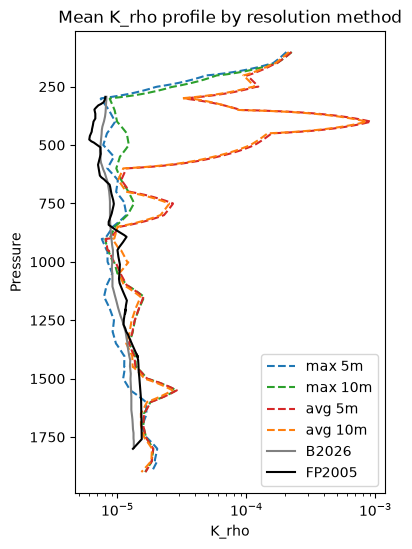

In [4]:
plt.figure(figsize=(4,6))
xr.open_dataset('/swot/SUM05/amf2288/NATRE_datasets/NATRE_Krho_max5.nc').Krho.mean('PROFILE').plot(y='PRESSURE', color='tab:blue', linestyle='--',label='max 5m')
xr.open_dataset('/swot/SUM05/amf2288/NATRE_datasets/NATRE_Krho_max10.nc').Krho.mean('PROFILE').plot(y='PRESSURE', color='tab:green', linestyle='--', label='max 10m')
xr.open_dataset('/swot/SUM05/amf2288/NATRE_datasets/NATRE_Krho_avg5.nc').Krho.mean('PROFILE').plot(y='PRESSURE', color='tab:red', linestyle='--',label='avg 5m')
xr.open_dataset('/swot/SUM05/amf2288/NATRE_datasets/NATRE_Krho_avg10.nc').Krho.mean('PROFILE').plot(y='PRESSURE', color='tab:orange', linestyle='--', label='avg 10m')
plt.plot(CB_K_rho[0], CB_K_rho[1], color='gray', label='B2026')
plt.plot(FP_K_rho[0], FP_K_rho[1], color='black', label='FP2005')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('K_rho')
plt.ylabel('Pressure')
plt.legend()
plt.title('Mean K_rho profile by resolution method')

# Calculating Cm

In [5]:
Krho = xr.open_dataset('/swot/SUM05/amf2288/NATRE_datasets/NATRE_Krho_max5.nc').Krho.mean('PROFILE').rename({'PRESSURE':'PRESSURE_mean'})
pbar = xr.open_dataset('/swot/SUM05/amf2288/NATRE_datasets/NATRE_pbar_max5.nc')
p    = xr.open_dataset('/swot/SUM05/amf2288/NATRE_datasets/NATRE_p_max5.nc')
CTvar_FB = ((ff.ds_filt_nan(pbar, 100, variable='CT_sort', dim1='PROFILE', dim2='PRESSURE_mean').differentiate('PRESSURE_mean'))**2).mean('PROFILE')
SAvar_FB = ((ff.ds_filt_nan(pbar, 100, variable='SA_sort', dim1='PROFILE', dim2='PRESSURE_mean').differentiate('PRESSURE_mean'))**2).mean('PROFILE')
print('done with FB')
CTvar_BC = (pbar.CT_sort.mean('PROFILE').differentiate('PRESSURE_mean'))**2
SAvar_BC = (pbar.SA_sort.mean('PROFILE').differentiate('PRESSURE_mean'))**2
print('done with BC')

CTterm3_FB = 2 * Krho * CTvar_FB
SAterm3_FB = 2 * Krho * SAvar_FB
CTterm3_BC = 2 * Krho * CTvar_BC
SAterm3_BC = 2 * Krho * SAvar_BC
print('done with all terms')

done with FB
done with BC
done with all terms


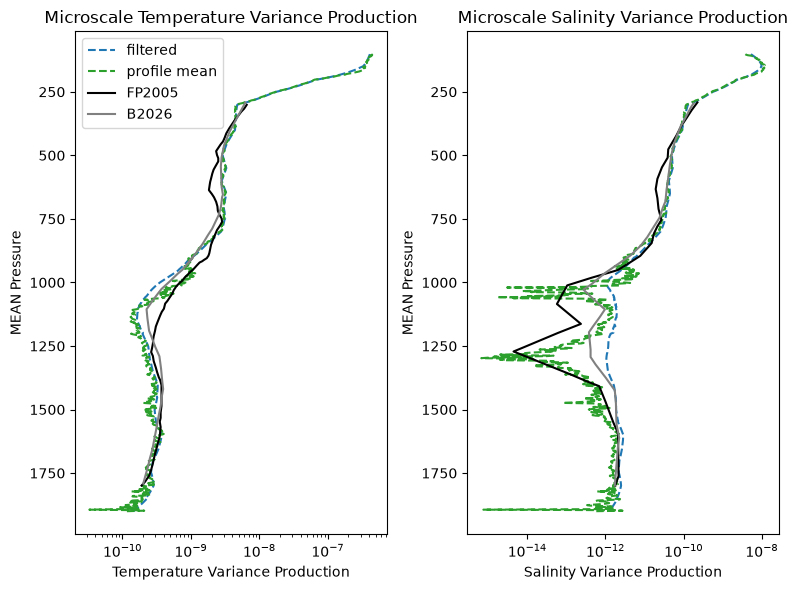

In [6]:
plt.figure(figsize=(8,6))

plt.subplot(121)
CTterm3_FB.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='filtered')
CTterm3_BC.plot(y='PRESSURE_mean', color='tab:green', linestyle='--', label='profile mean')
plt.plot(FP_P_perp_CT[0], FP_P_perp_CT[1], color='black', label='FP2005')
plt.plot(CB_P_perp_CT[0], CB_P_perp_CT[1], color='gray', label='B2026')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Temperature Variance Production')
plt.ylabel('MEAN Pressure')
plt.legend()
plt.title('Microscale Temperature Variance Production')

plt.subplot(122)
SAterm3_FB.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='filtered')
SAterm3_BC.plot(y='PRESSURE_mean', color='tab:green', linestyle='--', label='profile mean')
plt.plot(FP_P_perp_SA[0], FP_P_perp_SA[1], color='black', label='FP2005')
plt.plot(CB_P_perp_SA[0], CB_P_perp_SA[1], color='gray', label='B2026')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Salinity Variance Production')
plt.ylabel('MEAN Pressure')
plt.title('Microscale Salinity Variance Production')

plt.tight_layout()

# Calculating Ce

In [29]:
chiCT = 2 * Krho.rename({'PRESSURE_mean':'PRESSURE'}) * ff.ds_filt_nan((p.CT.differentiate('PRESSURE')**2).to_dataset(name='var'), 100, variable='var', dim1='PROFILE', dim2='PRESSURE').mean('PROFILE')
chiSA = 2 * Krho.rename({'PRESSURE_mean':'PRESSURE'}) * ff.ds_filt_nan((p.SA.differentiate('PRESSURE')**2).to_dataset(name='var'), 100, variable='var', dim1='PROFILE', dim2='PRESSURE').mean('PROFILE')

CTterm2_sub = chiCT - CTterm3_FB.rename({'PRESSURE_mean':'PRESSURE'})
SAterm2_sub = chiSA - SAterm3_FB.rename({'PRESSURE_mean':'PRESSURE'})

CTe = pbar.CT_sort - ff.ds_filt_nan(pbar, 100, variable='CT_sort', dim1='PROFILE', dim2='PRESSURE_mean')
SAe = pbar.SA_sort - ff.ds_filt_nan(pbar, 100, variable='SA_sort', dim1='PROFILE', dim2='PRESSURE_mean')

CTterm2_param = 2 * Krho *ff.ds_filt_nan((CTe.differentiate('PRESSURE_mean')**2).to_dataset(name='var'), 100, variable='var', dim1='PROFILE', dim2='PRESSURE_mean').mean('PROFILE')
SAterm2_param = 2 * Krho *ff.ds_filt_nan((SAe.differentiate('PRESSURE_mean')**2).to_dataset(name='var'), 100, variable='var', dim1='PROFILE', dim2='PRESSURE_mean').mean('PROFILE')

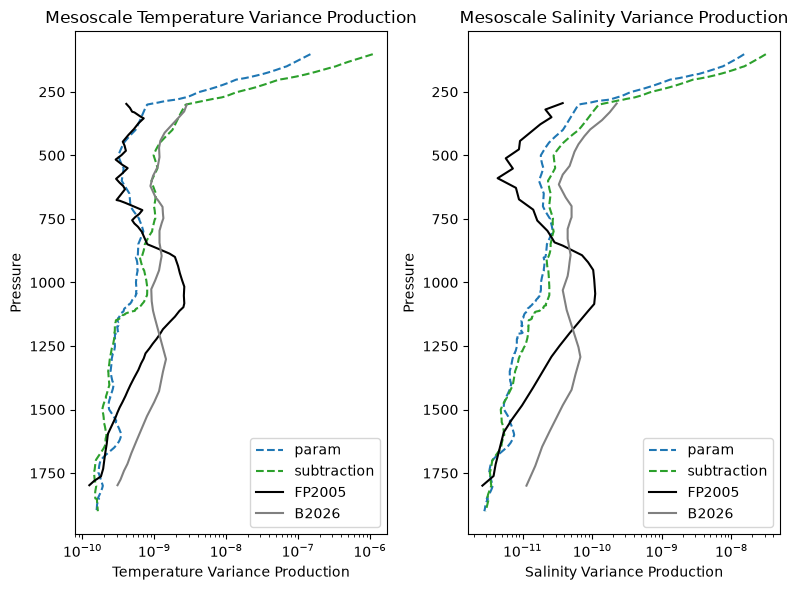

In [30]:
plt.figure(figsize=(8,6))

plt.subplot(121)
CTterm2_param.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='param')
CTterm2_sub.plot(y='PRESSURE', color='tab:green', linestyle='--', label='subtraction')
plt.plot(FP_P_para_CT[0], FP_P_para_CT[1], color='black', label='FP2005')
plt.plot(CB_P_para_CT[0], CB_P_para_CT[1], color='gray', label='B2026')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Temperature Variance Production')
plt.ylabel('Pressure')
plt.legend()
plt.title('Mesoscale Temperature Variance Production')

plt.subplot(122)
SAterm2_param.plot(y='PRESSURE_mean', color='tab:blue', linestyle='--', label='param')
SAterm2_sub.plot(y='PRESSURE', color='tab:green', linestyle='--', label='subtraction')
plt.plot(FP_P_para_SA[0], FP_P_para_SA[1], color='black', label='FP2005')
plt.plot(CB_P_para_SA[0], CB_P_para_SA[1], color='gray', label='B2026')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlabel('Salinity Variance Production')
plt.ylabel('Pressure')
plt.legend()
plt.title('Mesoscale Salinity Variance Production')

plt.tight_layout()